In [1]:
import numpy as np
import scipy as sp
import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)
import os
import pickle
import logging
import time
import sys
import matplotlib.pyplot as plt
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
lgcg_path = os.path.abspath(os.path.join('../nlgcg'))
if lgcg_path not in sys.path:
    sys.path.append(lgcg_path)
from lib.measure import Measure
from lib.ssn import SSN
from nlgcg import NLGCG

# Heat Equation

## Generate Data and Define Functions

In [54]:
logging.getLogger().setLevel(logging.INFO) # Supress logging

In [55]:
# Omega = np.array([[0,1], [0,1]])
# alpha = 1e-1
# observation_resolution = 4
# std_factor = 0.1
# true_sources = np.array([[0.28, 0.71], [0.51,0.27], [0.71,0.53]])
# true_weights = np.array([1,-0.7, 0.8])
# true_measure = Measure(support=true_sources, coefficients=true_weights)

In [56]:
Omega = np.array([[0,1], [0,1]])
alpha = 2e-1
observation_resolution = 10
std_factor = 0.02
np.random.seed(49)
true_sources = np.random.rand(20, 2)*0.9
true_weights = np.random.rand(20) * 2 - 1
true_measure = Measure(support=true_sources, coefficients=true_weights)

In [57]:
observations = (np.array(np.meshgrid(
                    *(
                        np.linspace(bound[0], bound[1], observation_resolution+2)
                        for bound in Omega
                    ))
            ).reshape(len(Omega), -1).T)
observations = np.array([obs for obs in observations if all(obs!=0) and all(obs!=1)])

In [58]:
@jax.jit
def kernel(omega: np.ndarray):
    outer_factor = np.sqrt(std_factor*np.pi)**Omega.shape[0]
    norms = -jnp.square(jnp.linalg.norm(omega-observations, axis=1))/std_factor # (len(x),)
    exponentiated = jnp.exp(norms)/outer_factor # (len(x),)
    return exponentiated

grad_kernel = jax.jit(jax.jacobian(kernel))
hess_kernel = jax.jit(jax.hessian(kernel))
_ = grad_kernel(true_sources[0])
_ = hess_kernel(true_sources[0])

kernel = jax.vmap(kernel)
grad_kernel = jax.vmap(grad_kernel)
hess_kernel = jax.vmap(hess_kernel)

In [ ]:
target = true_measure.duality_pairing(kernel)

@jax.jit
def g(w: np.ndarray) -> float:
    return alpha * jnp.linalg.norm(w, ord=1)
# grad_g = jax.jit(jax.grad(g))
# _ = grad_g(jnp.ones(1))

@jax.jit
def f(y: np.ndarray) -> float:
    return 0.5 * jnp.sum((y - target)**2)
f_grad = jax.jit(jax.grad(f))
_ = f_grad(jnp.zeros(target.shape[0]))

j = lambda u: f(u.duality_pairing(kernel)) + g(u.coefficients)

In [60]:
def p(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: kernel(omega) @ inner

def grad_P(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: np.tensordot(grad_kernel(omega), inner, axes=([1,0]))

def hess_P(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: np.tensordot(hess_kernel(omega), inner, axes=([1,0]))

In [61]:
@jax.jit
def j_N(input: np.ndarray):
    input = input.reshape(-1, Omega.shape[0]+1)
    weights = input[:,0]
    omega = input[:,1:]
    return f(kernel(omega).T@weights) + g(weights)

grad_j_N = jax.jit(jax.grad(j_N))
hess_j_N = jax.jit(jax.hessian(j_N))
_ = grad_j_N(np.ones((2, Omega.shape[0]+1)).flatten())
_ = hess_j_N(np.ones((2, Omega.shape[0]+1)).flatten())

## Experiments

In [ ]:
exp = NLGCG(target=target, 
           kernel=kernel, 
           g=g, 
           j=j,
           j_N=j_N,
           p=p,
           grad_P=grad_P,
           hess_P=hess_P,
           grad_j_N=grad_j_N,
           hess_j_N=hess_j_N,
           alpha=alpha,
           Omega=Omega,
           global_search_resolution=4,
           dual_variable_goodness=0.3,
           armijo_constant=0.1
           )

In [63]:
u, times, supports, inner_loop, lgcg_lazy, lgcg_total, objective_values, dropped_tot, epsilons = exp.nlgcg(tol=1e-12, max_radius=0.1, mode="stochastic")

INFO:root:0: choice: 0, lazy: True, support: 0, epsilon: 1.000E-01, criterion: 3.050E+03, c_raw: 1024.0, objective: 3.049828929510E+03
INFO:root:=============================================================================================
INFO:root:SSN in 1 dimensions converged in 3 iterations to tolerance 1.000E-12
INFO:root:1, 1: Globalization: Newt, support: 1, c_raw: 1.02E+03, sigma: 1.00E+00, epsilon: 1.00E-01, criterion: 2.11E+03, objective: 2.086891612700E+03
INFO:root:1, 2: Globalization: Newt, support: 1, c_raw: 1.02E+03, sigma: 1.00E+00, epsilon: 1.00E-01, criterion: 2.11E+03, objective: 2.086776157180E+03
INFO:root:1, 3: Globalization: Newt, support: 1, c_raw: 1.02E+03, sigma: 1.00E+00, epsilon: 1.00E-01, criterion: 2.11E+03, objective: 2.086776155803E+03
INFO:root:1, 4: Globalization: Newt, support: 1, c_raw: 1.02E+03, sigma: 1.00E+00, epsilon: 1.00E-01, criterion: 2.11E+03, objective: 2.086776155803E+03
INFO:root:Descent test: False
INFO:root:1: choice: 2, lazy: True, supp

In [84]:
np.array(times)

array([2.38418579e-07, 5.47930956e-01, 9.97617960e-01, 1.08187580e+00,
       1.08919501e+00, 1.09600449e+00, 1.68351293e+00, 1.69106507e+00,
       1.69823408e+00, 1.70548487e+00, 1.71303964e+00, 1.77242565e+00,
       2.57257915e+00, 3.34266138e+00, 3.46008801e+00, 3.91038465e+00,
       4.43119001e+00, 4.50289369e+00, 4.51165295e+00, 4.52105784e+00,
       5.28908253e+00, 5.35930586e+00, 5.36606359e+00, 5.37311816e+00,
       5.38149357e+00, 5.80904126e+00, 6.50646091e+00, 7.09097242e+00,
       7.70746493e+00, 7.82062244e+00, 7.83320332e+00, 7.84265661e+00,
       8.49737263e+00, 8.81602597e+00, 8.47772241e+00, 9.21935225e+00,
       9.91666198e+00, 1.03006904e+01, 1.09412100e+01, 1.12075548e+01,
       1.17638617e+01, 1.19972603e+01, 1.25154023e+01, 1.26781902e+01,
       1.34024508e+01, 1.36221633e+01, 1.36318948e+01, 1.42847121e+01,
       1.49716671e+01, 1.50402415e+01, 1.56043720e+01, 1.61667120e+01,
       1.66924262e+01, 1.67141268e+01, 1.74229429e+01, 1.77035940e+01,
      

In [64]:
print(u)

Measure with support
[[0.11274953 0.40142876]
 [0.22559503 0.81962004]
 [0.2259064  0.8196895 ]
 [0.2264966  0.8209238 ]
 [0.25682251 0.285603  ]
 [0.27213714 0.06332378]
 [0.27229694 0.06244045]
 [0.27266491 0.06317047]
 [0.29236501 0.32840575]
 [0.29370833 0.3308349 ]
 [0.29630473 0.33400281]
 [0.32480784 0.38421703]
 [0.32648556 0.3879204 ]
 [0.4037587  0.72201585]
 [0.40455758 0.72159269]
 [0.40480566 0.72256862]
 [0.40988097 0.47937587]
 [0.48309637 0.18926033]
 [0.48456684 0.18868179]
 [0.48470669 0.18913324]
 [0.54917019 0.16903174]
 [0.55861471 0.97618191]
 [0.55993244 0.97630258]
 [0.6027604  0.63487301]
 [0.60447079 0.36847537]
 [0.60555037 0.36898978]
 [0.62134124 0.80860604]
 [0.65546694 0.45241817]
 [0.65560011 0.4518544 ]
 [0.65582728 0.45259633]
 [0.68071939 0.62025644]
 [0.68121487 0.61933857]
 [0.68306591 0.6189336 ]
 [0.71360087 0.19448125]
 [0.71409255 0.19383728]
 [0.73559329 0.81827249]
 [0.73559954 0.81879234]
 [0.76206518 0.56581786]
 [0.80267216 0.76944424]
 [0.

In [89]:
hesses = exp.hess_P(u)(u.support)
grads = exp.grad_P(u)(u.support)

In [90]:
np.linalg.eigvals(hesses[5])

array([44.68196309,  0.39946737])

In [93]:
u.to_matrix().shape

(54, 3)

In [94]:
hess = hess_j_N(u.to_matrix().flatten())
np.linalg.eigvals(hess)

array([ 5.76565448e+04,  5.42525301e+04,  2.63663860e+04,  2.21007777e+04,
        1.90959974e+04,  1.66579687e+04,  1.23046876e+04,  1.13226365e+04,
        9.75754753e+03,  8.69342281e+03,  7.89772729e+03,  7.99485301e+03,
        7.01535119e+03,  6.41287763e+03,  5.48685349e+03,  5.09995018e+03,
        4.04330241e+03,  3.45022064e+03,  2.94843013e+03,  2.62910989e+03,
        2.40156577e+03,  1.83744563e+03,  1.50577212e+03,  1.36698221e+03,
        1.15316355e+03,  9.12992912e+02,  7.82709097e+02,  7.37282768e+02,
        6.29789971e+02,  5.37434049e+02,  4.62034373e+02,  4.07798756e+02,
        3.85048073e+02,  3.09571044e+02,  2.47055452e+02,  2.10431792e+02,
        1.49481900e+02,  1.45976971e+02,  1.21178998e+02,  9.33119930e+01,
        7.10098283e+01,  5.54526735e+01,  3.30617076e+01,  3.23381282e+01,
        2.80962035e+01,  2.65934689e+01,  2.46596469e+01,  2.06577264e+01,
        1.59461256e+01,  1.31940233e+01,  1.21404779e+01,  1.14903546e+01,
        1.04034247e+01,  

## Plots

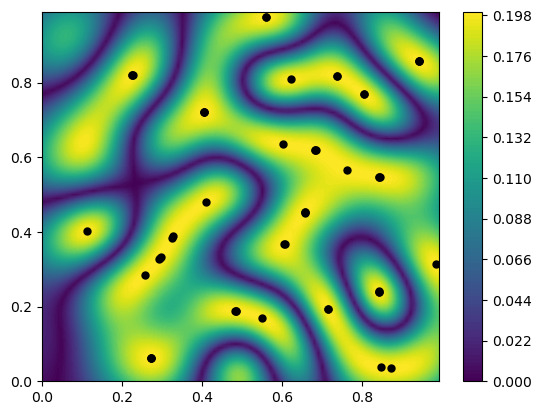

In [65]:
p_u = p(u)
a = np.arange(0,1,0.01)
x, y = np.meshgrid(a,a)
points = np.array(list(zip(x.flatten(), y.flatten())))
vals = np.abs(p_u(points)).reshape((100,100))

plt.contourf(x, y, vals, levels=100);
for omega in u.support:
    plt.plot(omega[0], omega[1], "o", c="black", markersize=5);
plt.colorbar();

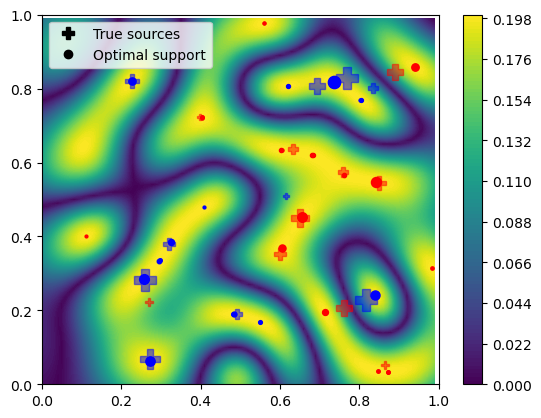

In [13]:
p_u = p(u)
P = lambda x: np.abs(p_u(x))
a = np.arange(0,1,0.01)
B, D = np.meshgrid(a,a)
points = np.array(list(zip(B.flatten(), D.flatten())))
vals = P(points).reshape((100,100))

plt.contourf(B, D, vals, levels=100);
plt.colorbar();
plt.plot(Omega[0][0]-1, Omega[0][1]-1, "P", c="black", markersize=8, label="True sources");
plt.plot(Omega[0][0]-1, Omega[0][1]-1, "o", c="black", label="Optimal support");
plt.xlim(Omega[0][0], Omega[0][1]);
plt.ylim(Omega[1][0], Omega[1][1]);
for i, x in enumerate(true_sources):
    if true_weights[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(true_weights[i]) * 12 + 4
    plt.plot([x[0]], [x[1]], "P", alpha=0.5, c=color, markersize=size);
for i, x in enumerate(u.support):
    if u.coefficients[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(u.coefficients[i]) * 10 + 2
    plt.plot([x[0]], [x[1]], "o", c=color, markersize=size);
plt.legend();

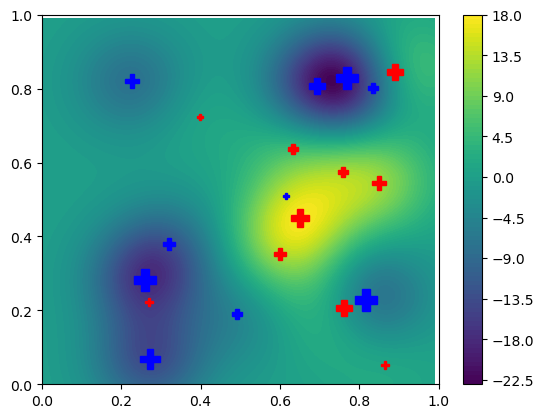

In [15]:
# Plot the measured heat distribution
def heat(x):
    # Input is 2D array of shape (number of points, Omega dimension)
    if len(x.shape) == 1:
        x = x.reshape(1, -1) 
    weighted_heat = np.zeros(x.shape[0]) # (len(x),)
    outer_factor = np.sqrt(std_factor*np.pi)**Omega.shape[0]
    for point, weight in zip(true_sources, true_weights):
        diff = point-x # (len(x), Omega.shape[0])
        norms = -np.square(np.linalg.norm(diff, axis=1))/std_factor # (len(x),)
        exponentiated = np.exp(norms) # (len(x),)
        weighted_heat += exponentiated * weight # (len(x),)
    result = weighted_heat/outer_factor # shape=(len(x),)
    return result

a = np.arange(0,1,0.01)
B, D = np.meshgrid(a,a)
x = np.array(list(zip(B.flatten(), D.flatten())))
true_vals = heat(x).reshape((100,100))

plt.contourf(B, D, true_vals, levels=100);
plt.colorbar();
plt.xlim(Omega[0][0], Omega[0][1]);
plt.ylim(Omega[1][0], Omega[1][1]);
for i, x in enumerate(true_sources):
    if true_weights[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(true_weights[i]) * 12 + 4
    plt.plot([x[0]], [x[1]], "P", c=color, markersize=size);

L2 error: 8.397E-02, Linf error: 1.013E+00


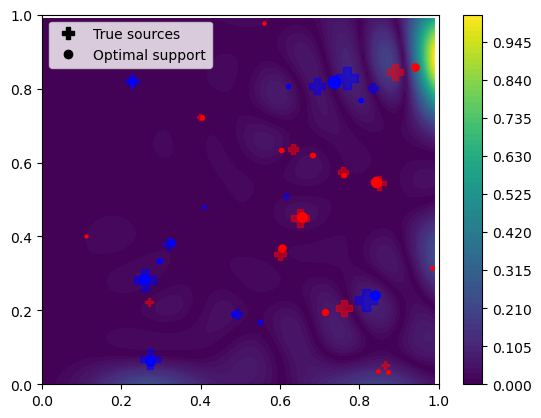

In [16]:
def predicted_heat(x):
    # Input is 2D array of shape (number of points, Omega dimension)
    if len(x.shape) == 1:
        x = x.reshape(1, -1) 
    weighted_heat = np.zeros(x.shape[0]) # (len(x),)
    outer_factor = np.sqrt(std_factor*np.pi)**Omega.shape[0]
    for point, weight in zip(u.support, u.coefficients):
        diff = point-x # (len(x), Omega.shape[0])
        norms = -np.square(np.linalg.norm(diff, axis=1))/std_factor # (len(x),)
        exponentiated = np.exp(norms) # (len(x),)
        weighted_heat += exponentiated * weight # (len(x),)
    result = weighted_heat/outer_factor # shape=(len(x),)
    return result

a = np.arange(0,1,0.01)
B, D = np.meshgrid(a,a)
x = np.array(list(zip(B.flatten(), D.flatten())))
pred_vals = predicted_heat(x).reshape((100,100))
error = true_vals - pred_vals

print(f"L2 error: {np.linalg.norm(error)/np.sqrt(len(x)):.3E}, Linf error: {np.max(np.abs(error)):.3E}")

plt.contourf(B, D, np.abs(error), levels=100);
plt.colorbar();
plt.plot(Omega[0][0]-1, Omega[0][1]-1, "P", c="black", markersize=8, label="True sources");
plt.plot(Omega[0][0]-1, Omega[0][1]-1, "o", c="black", label="Optimal support");
plt.xlim(Omega[0][0], Omega[0][1]);
plt.ylim(Omega[1][0], Omega[1][1]);
for i, x in enumerate(true_sources):
    if true_weights[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(true_weights[i]) * 12 + 4
    plt.plot([x[0]], [x[1]], "P", alpha=0.5, c=color, markersize=size);
for i, x in enumerate(u.support):
    if u.coefficients[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(u.coefficients[i]) * 10 + 2
    plt.plot([x[0]], [x[1]], "o", c=color, markersize=size);
plt.legend();

# Signal Processing

## Generate Data and Define Functions

In [2]:
logging.getLogger().setLevel(logging.INFO) # Supress logging

In [3]:
# observation_resolution = 120
# Omega = np.array([[0,observation_resolution//2]])
# alpha = 1e-1
# true_sources = np.array([[3.125], [7], [np.sqrt(179)]])
# true_weights = np.array([-1, 0.7, 0.5])
# true_measure = Measure(support=true_sources, coefficients=true_weights)

In [4]:
alpha = 1e-0
source_number = 20
observation_resolution = 100
Omega = np.array([[0,observation_resolution//2]])
np.random.seed(49)
true_sources = np.array(np.random.rand(source_number)*50)
true_weights = np.random.rand(source_number) * 2 - 1
true_measure = Measure(support=true_sources, coefficients=true_weights)

In [5]:
observations = np.arange(0,1,1/observation_resolution)

In [6]:
@jax.jit
def kernel(omega: np.ndarray):
    return jnp.sin(2*np.pi*omega*observations).flatten()

grad_kernel = jax.jit(jax.jacobian(kernel))
hess_kernel = jax.jit(jax.hessian(kernel))
_ = grad_kernel(true_sources[0])
_ = hess_kernel(true_sources[0])

kernel = jax.vmap(kernel)
grad_kernel = jax.vmap(grad_kernel)
hess_kernel = jax.vmap(hess_kernel)

INFO:jax._src.xla_bridge:Unable to initialize backend 'cuda': 
INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [ ]:
target = true_measure.duality_pairing(kernel)

@jax.jit
def g(w: np.ndarray) -> float:
    return alpha * jnp.linalg.norm(w, ord=1)
# grad_g = jax.jit(jax.grad(g))
# _ = grad_g(jnp.ones(1))

@jax.jit
def f(y: np.ndarray) -> float:
    return 0.5 * jnp.sum((y - target)**2)
f_grad = jax.jit(jax.grad(f))
_ = f_grad(jnp.zeros(target.shape[0]))

j = lambda u: f(u.duality_pairing(kernel)) + g(u.coefficients)

In [8]:
def p(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: kernel(omega) @ inner

def grad_P(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: np.tensordot(grad_kernel(omega), inner, axes=([1,0]))

def hess_P(u):
    inner = -f_grad(u.duality_pairing(kernel, len(target)))
    return lambda omega: np.tensordot(hess_kernel(omega), inner, axes=([1,0]))

In [9]:
@jax.jit
def j_N(input: np.ndarray):
    input = input.reshape(-1, Omega.shape[0]+1)
    weights = input[:,0]
    omega = input[:,1:]
    return f(kernel(omega).T@weights) + g(weights)

grad_j_N = jax.jit(jax.grad(j_N))
hess_j_N = jax.jit(jax.hessian(j_N))
_ = grad_j_N(np.ones((2, Omega.shape[0]+1)).flatten())
_ = hess_j_N(np.ones((2, Omega.shape[0]+1)).flatten())

## Experiments

In [10]:
exp = NLGCG(target=target, 
           kernel=kernel, 
           g=g, 
           j=j,
           j_N=j_N,
           p=p,
           grad_P=grad_P,
           hess_P=hess_P,
           grad_j_N=grad_j_N,
           hess_j_N=hess_j_N,
           alpha=alpha,
           Omega=Omega,
           global_search_resolution=1000,
           dual_variable_goodness=0.5,
           armijo_constant=0.1
           )

In [11]:
u, times, supports, inner_loop, lgcg_lazy, lgcg_total, objective_values, dropped_tot, epsilons = exp.nlgcg(tol=1e-12, max_radius=1, mode="stochastic")

INFO:root:0: choice: 0, lazy: True, support: 0, epsilon: 5.000E-01, criterion: 1.801E+02, c_raw: 64.0, objective: 1.801329571459E+02
INFO:root:=============================================================================================
INFO:root:SSN in 2 dimensions converged in 3 iterations to tolerance 1.000E-12
INFO:root:1, 1: Globalization: Newt, support: 2, c_raw: 6.40E+01, sigma: 1.00E+00, epsilon: 5.00E-01, criterion: 1.37E+02, objective: 1.370736511572E+02
INFO:root:1, 2: Globalization: Newt, support: 2, c_raw: 6.40E+01, sigma: 1.00E+00, epsilon: 5.00E-01, criterion: 1.37E+02, objective: 1.370731980977E+02
INFO:root:1, 3: Globalization: Newt, support: 2, c_raw: 6.40E+01, sigma: 1.00E+00, epsilon: 5.00E-01, criterion: 1.37E+02, objective: 1.370731980962E+02
INFO:root:1, 4: Globalization: Newt, support: 2, c_raw: 3.20E+01, sigma: 1.00E+00, epsilon: 5.00E-01, criterion: 1.37E+02, objective: 1.370731980962E+02
INFO:root:Descent test: False
INFO:root:1: choice: 2, lazy: True, suppor

KeyboardInterrupt: 

In [ ]:
np.array(times)

array([2.38418579e-07, 8.21671486e-02, 9.65368748e-02, 1.06063604e-01,
       1.15900993e-01, 1.25293493e-01, 1.62534475e-01, 7.24710464e-01,
       8.44991207e-01, 9.63671684e-01, 1.07399631e+00, 1.13877678e+00,
       1.14945626e+00, 1.15921497e+00, 1.20162296e+00, 1.21202040e+00,
       1.22244954e+00, 1.23348475e+00, 1.24469113e+00, 1.29558420e+00,
       1.30664349e+00, 1.31743121e+00, 1.32961130e+00, 1.34084177e+00,
       1.37031126e+00, 1.38222575e+00, 1.39391446e+00, 1.40623879e+00,
       1.41813707e+00, 1.44561100e+00, 1.45760846e+00, 1.46990514e+00,
       1.48198438e+00, 1.49412775e+00, 1.57799506e+00, 1.58847260e+00,
       1.59698868e+00, 1.60561323e+00, 1.61405516e+00, 1.77561259e+00,
       1.88686252e+00, 2.06327796e+00, 2.18716908e+00, 2.36664653e+00,
       2.47578001e+00, 2.60929918e+00, 2.63077211e+00, 2.71160412e+00,
       2.73344326e+00, 2.84338713e+00, 2.86845279e+00, 2.95126581e+00,
       2.97502208e+00, 2.98668742e+00, 2.99827051e+00, 3.15912890e+00,
      

In [ ]:
dropped_tot

0

In [ ]:
print(u)

Measure with support
[[ 2.94461537]
 [10.52713405]
 [11.45068321]
 [12.34335735]
 [14.39685242]
 [14.92358598]
 [15.72102378]
 [22.10845188]
 [24.93706121]
 [27.35056811]
 [28.33207758]
 [34.16941726]
 [36.08959603]
 [38.48359335]
 [40.11290233]
 [42.23745551]
 [44.24322824]
 [44.85980959]
 [46.32363315]
 [48.10773424]]
and coefficients
[ 0.8240666  -0.48045173  0.849974    0.3817211   0.21584669  0.42726536
 -0.15345696  0.66251647  0.80199806  0.79031867 -0.13849679 -0.26806017
 -0.47428462 -0.38219457  0.25920887  0.96088575  0.03849755 -0.67767064
  0.85966104  0.68192501]


## Plots

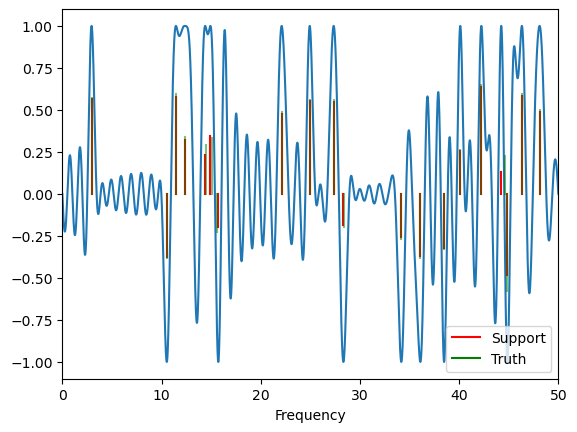

In [ ]:
a = np.arange(Omega[0][0],Omega[0][1],0.001)
p_u = p(u)
vals = p_u(a)
plt.plot(a,vals);
plt.axvline(x=-1, linestyle="-", c="r", label="Support");
plt.axvline(x=-1, linestyle="-", c="g", label="Truth");
for i, pos in enumerate(u.support):
    ymax = 0.5+(u.coefficients[i]*alpha*0.25+0.05*np.sign(u.coefficients[i]))
    plt.axvline(x=pos, ymin=0.5,ymax=ymax, linestyle="-", c="r");
for point, weight in  zip(true_sources, true_weights):
    ymax = 0.5+(weight*alpha*0.25+0.05*np.sign(weight))
    plt.axvline(x=point, ymin=0.5,ymax=ymax,alpha=0.5, linestyle="-", c="g");
plt.xlabel("Frequency");
plt.ylim(-alpha*1.1,alpha*1.1);
plt.xlim(0, 50);
plt.legend();

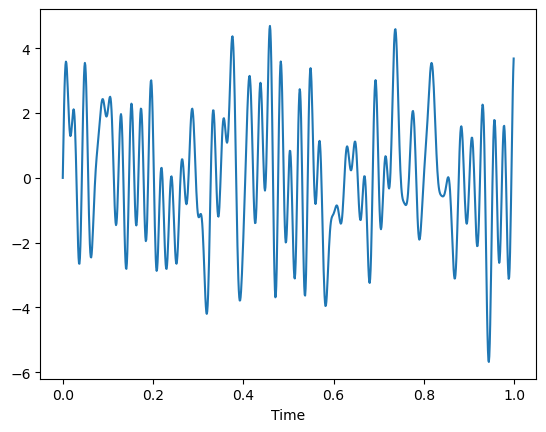

In [ ]:
# Plot the measured signal
def signal(x):
    # Input is 2D array of shape (number of points, Omega dimension)
    weighted_signal = 0
    for point, weight in zip(true_sources, true_weights):
        weighted_signal += weight*np.sin(2*np.pi*point*x).flatten()
    return weighted_signal

a = np.arange(0,1,0.001)
true_signal = signal(a)
plt.plot(a, true_signal);
plt.xlabel("Time");

L2 error: 0.07752247278306637, Linf error: 0.4340879462119944


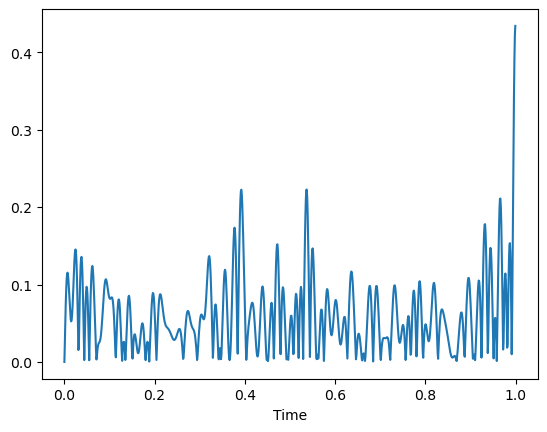

In [ ]:
# Plot the measured signal
def signal(x):
    # Input is 2D array of shape (number of points, Omega dimension)
    weighted_signal = 0
    for point, weight in zip(u.support, u.coefficients):
        weighted_signal += weight*np.sin(2*np.pi*point*x).flatten()
    return weighted_signal

a = np.arange(0,1,0.001)
predicted_signal = signal(a)
error = true_signal - predicted_signal
print(f"L2 error: {np.linalg.norm(error)/np.sqrt(len(a))}, Linf error: {np.max(np.abs(error))}")
plt.plot(a, np.abs(true_signal-predicted_signal));
plt.xlabel("Time");

# Function Approximation (Gaussian Shallow NN)

## Generate Data and Define Functions

In [172]:
logging.getLogger().setLevel(logging.INFO) # Supress logging

In [173]:
# sigma_space = np.array([[0,1]])
# omega_space = np.array([[0,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-3
# observation_resolution = 100
# endpoint = True
# true_sigma = np.array([0.06, 0.05, 0.04])
# true_omega = np.array([[0.28], [0.51], [0.71]])
# true_sources = np.hstack((true_sigma.reshape(-1,1), true_omega))
# true_weights = np.array([1, -0.7, 0.8])
# true_measure = Measure(support=true_sources, coefficients=true_weights)
# method = "measure"

In [174]:
# sigma_space = np.array([[0,1]])
# omega_space = np.array([[0,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-3
# observation_resolution = 100
# endpoint = True
# np.random.seed(49)
# true_sigma = np.random.rand(10)*0.1
# true_omega = (np.random.rand(10, 1)-np.array([0.5]))*0.9+np.array([0.5])
# true_sources = np.hstack((true_sigma.reshape(-1,1), true_omega))
# true_weights = np.random.rand(10) * 2 - 1
# true_measure = Measure(support=true_sources, coefficients=true_weights)
# method = "measure"

In [175]:
# sigma_space = np.array([[0,1]])
# omega_space = np.array([[-1,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-3
# observation_resolution = 100
# endpoint = True

# true_function = lambda x: sp.special.expit(100*x).flatten()
# method = "function"

In [176]:
# sigma_space = np.array([0,1])
# omega_space = np.array([[0,1], [0,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-3
# observation_resolution = 25
# endpoint = True
# true_sigma = np.array([0.06, 0.05, 0.04])
# true_omega = np.array([[0.28, 0.71], [0.51,0.27], [0.71,0.53]])
# true_sources = np.hstack((true_sigma.reshape(-1,1), true_omega))
# true_weights = np.array([1, -0.7, 0.8])
# true_measure = Measure(support=true_sources, coefficients=true_weights)
# method = "measure"

In [177]:
# sigma_space = np.array([0,1])
# omega_space = np.array([[0,1], [0,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 3e-2
# observation_resolution = 25
# endpoint = True
# np.random.seed(49)
# true_sigma = np.random.rand(20)*0.2
# true_omega = (np.random.rand(20, 2)-np.array([0.5,0.5]))*0.9+np.array([0.5,0.5])
# true_sources = np.hstack((true_sigma.reshape(-1,1), true_omega))
# true_weights = np.random.rand(20) * 2 - 1
# true_measure = Measure(support=true_sources, coefficients=true_weights)
# method = "measure"

In [178]:
# sigma_space = np.array([0,1])
# omega_space = np.array([[-1,1], [-1,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-2
# observation_resolution = 10
# endpoint = True

# def my_funct(x: np.ndarray, c: np.ndarray, k: float, r: float):
#     return np.tanh(k*(r-np.linalg.norm(x-c,axis=1)))+1

# c_1 = np.array([0.3,0.3])
# k_1 = 4
# r_1 = 0.3
# c_2 = -c_1
# k_2 = 12
# r_2 = 0.15
# true_function = lambda x: my_funct(x, c_1, k_1, r_1) + my_funct(x, c_2, k_2, r_2)
# method = "function"

In [ ]:
sigma_space = np.array([0,1])
omega_space = np.array([[-1,1], [-1,1]])
Omega = np.vstack((sigma_space, omega_space))
d = omega_space.shape[0]
variance_exponent = 0.1
alpha = 1e-2
observation_resolution = 5
endpoint = False

true_function = lambda x: np.minimum(1-np.abs(x[:,0]), 1-np.abs(x[:,1]))
method = "function"

In [ ]:
# sigma_space = np.array([0,1])
# omega_space = np.array([[-1,1], [-1,1], [-1,1], [-1,1]])
# Omega = np.vstack((sigma_space, omega_space))
# d = omega_space.shape[0]
# variance_exponent = 0.1
# alpha = 1e-2
# observation_resolution = 5
# endpoint = False

# def my_funct(x: np.ndarray):
#     to_return = np.ones(x.shape[0])
#     for i in range(x.shape[1]):
#         to_return *= np.sin(np.pi*x[:,i])
#     return to_return

# true_function = lambda x: my_funct(x)
# method = "function"

In [180]:
observations = (np.array(np.meshgrid(
                    *(
                        np.linspace(bound[0]+1e-5, bound[1]-1e-5, observation_resolution, endpoint=endpoint)
                        for bound in omega_space
                    ))
            ).reshape(len(omega_space), -1).T)
observations = np.array([obs for obs in observations])# if all(obs!=0) and all(obs!=1)])

In [181]:
@jax.jit
def kernel(omega: np.ndarray):
    sigma = omega[0]
    x = omega[1:]
    inner = -(jnp.linalg.norm(x - observations,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**(variance_exponent))/(np.sqrt(2*np.pi)**d)
    return outer

grad_kernel = jax.jit(jax.jacobian(kernel))
hess_kernel = jax.jit(jax.hessian(kernel))
_ = grad_kernel(np.ones(len(Omega)))
_ = hess_kernel(np.ones(len(Omega)))

kernel = jax.vmap(kernel)
grad_kernel = jax.vmap(grad_kernel)
hess_kernel = jax.vmap(hess_kernel)

In [182]:
if method == "measure":
    target = true_measure.duality_pairing(kernel)
elif method == "function":
    target = true_function(observations)

In [183]:
@jax.jit
def g(w: np.ndarray) -> float:
    return alpha * jnp.linalg.norm(w, ord=1)
grad_g = jax.jit(jax.grad(g))
_ = grad_g(jnp.ones(1))

@jax.jit
def f(y: np.ndarray) -> float:
    return 0.5 * jnp.sum((y - target)**2)
grad_f = jax.jit(jax.grad(f))
hess_f = jax.jit(jax.hessian(f))
_ = grad_f(jnp.zeros(target.shape[0]))
_ = hess_f(jnp.zeros(target.shape[0]))

j = lambda u, c: f(u.duality_pairing(kernel)+c*np.ones(target.shape)) + g(u.coefficients)

In [184]:
def p(u, c):
    inner = -grad_f(u.duality_pairing(kernel, len(target))+c*np.ones(target.shape))
    return lambda omega: kernel(omega) @ inner

def grad_P(u, c):
    inner = -grad_f(u.duality_pairing(kernel, len(target))+c*np.ones(target.shape))
    return lambda omega: np.tensordot(grad_kernel(omega), inner, axes=([1,0]))

def hess_P(u, c):
    inner = -grad_f(u.duality_pairing(kernel, len(target))+c*np.ones(target.shape))
    return lambda omega: np.tensordot(hess_kernel(omega), inner, axes=([1,0]))

In [185]:
@jax.jit
def j_N(raw_input: np.ndarray):
    constant = raw_input[-1]
    input = raw_input[:-1].reshape(-1, d+2)
    weights = input[:,0]
    omega = input[:,1:]
    return f(kernel(omega).T@weights+constant*jnp.ones(target.shape)) + g(weights)

grad_j_N = jax.jit(jax.grad(j_N))
hess_j_N = jax.jit(jax.hessian(j_N))
# for i in range(10):
#     _ = j_N(np.ones(i*(d+2)+1))
#     _ = grad_j_N(np.ones(i*(d+2)+1))
#     _ = hess_j_N(np.ones(i*(d+2)+1))

## Alternative Approach

In [270]:
peaks, _ = sp.signal.find_peaks(target, prominence=0)

In [271]:
def gaussian(x, sigma, x_0, coefficient, constant):
    return coefficient * np.exp(-(x-x_0)**2 / (2*sigma**2)) + constant

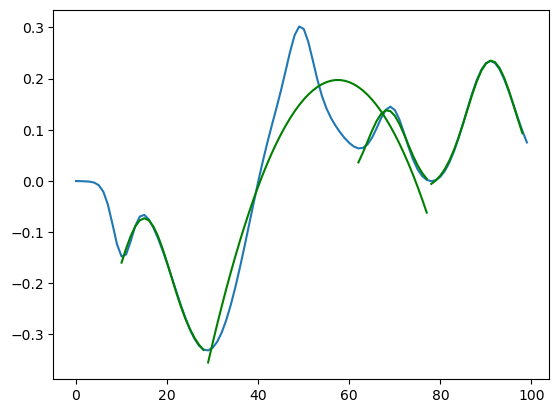

In [275]:
plt.plot(target)
for i, peak in enumerate(peaks):
    interval = np.array(list(range(_["left_bases"][i], _["right_bases"][i])))
    popt, pcov = sp.optimize.curve_fit(gaussian, interval, target[interval],p0=[1,peak,1,0])
    plt.plot(interval, gaussian(interval, *popt), color="green")

## Experiments

In [186]:
exp = NLGCG(target=target, 
           kernel=kernel, 
           g=g,
           f=f,
           grad_f=grad_f,
           hess_f=hess_f,
           j=j,
           j_N=j_N,
           p=p,
           grad_P=grad_P,
           hess_P=hess_P,
           grad_j_N=grad_j_N,
           hess_j_N=hess_j_N,
           alpha=alpha,
           Omega=Omega,
           global_search_resolution=10,
           dual_variable_goodness=0.3,
           armijo_constant=1e-1,
           )

In [187]:
u, c, times, supports, inner_loop, lgcg_lazy, lgcg_total, objective_values, dropped_tot, epsilons = exp.nlgcg(tol=1e-9, max_radius=0.1, mode="stochastic")

INFO:root:SSN in 1 dimensions converged in 0 iterations to tolerance 1.000E-12
INFO:root:0: choice: 0, lazy: True, support: [], epsilon: 5.000E-03, criterion: 1.953E+01, c_raw: 1.0, objective: 1.953156900476E+01
INFO:root:=============================================================================================
INFO:root:SSN in 10 dimensions and tolerance 1.000E-12: MAX ITERATIONS REACHED, 2.607E-12 achieved
INFO:root:[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
INFO:root:1, 0: Globalization: NotA, support: 8, c_raw: 1.00E+00, sigma: 0.00E+00, epsilon: 5.00E-03, criterion: 1.77E+01, objective: 1.769356381390E+01
INFO:root:1, 1: Globalization: Grad, support: 8, c_raw: 1.00E+00, sigma: 3.12E-02, epsilon: 5.00E-03, criterion: 1.77E+01, objective: 1.727420841824E+01
INFO:root:1, 2: Globalization: Grad, support: 8, c_raw: 1.00E+00, sigma: 7.81E-03, epsilon: 5.00E-03, criterion: 1.77E+01, objective: 1.718015614698E+01
INFO:root:1, 3: Globalization: Grad, support: 8, c_raw: 1.00E+00, sigma: 1.

In [188]:
full_parameters = np.hstack((u.to_matrix().flatten(), c))

In [189]:
grd = exp.grad_j_N(full_parameters)
np.linalg.norm(grd)

3.98155368286892e-10

In [190]:
hss = exp.hess_j_N(full_parameters)
np.linalg.eigvals(hss)

array([8.70023713e+02+0.00000000e+00j, 2.18208034e+02+0.00000000e+00j,
       1.40465716e+02+0.00000000e+00j, 8.30879547e+01+0.00000000e+00j,
       7.63233282e+01+0.00000000e+00j, 2.09497264e+02+0.00000000e+00j,
       2.09497264e+02+0.00000000e+00j, 2.09497264e+02+0.00000000e+00j,
       4.31770575e+01+0.00000000e+00j, 1.33075690e+02+0.00000000e+00j,
       1.33075690e+02+0.00000000e+00j, 1.35618073e+02+0.00000000e+00j,
       1.35618073e+02+0.00000000e+00j, 1.35618073e+02+0.00000000e+00j,
       7.90224535e+01+0.00000000e+00j, 7.90224535e+01+0.00000000e+00j,
       7.90224535e+01+0.00000000e+00j, 2.20606803e+01+0.00000000e+00j,
       2.20606803e+01+0.00000000e+00j, 2.20606803e+01+0.00000000e+00j,
       4.75091671e+00+0.00000000e+00j, 1.72290128e+01+0.00000000e+00j,
       1.38138300e+01+0.00000000e+00j, 1.55727172e+01+0.00000000e+00j,
       1.90936879e+01+0.00000000e+00j, 1.90936879e+01+0.00000000e+00j,
       1.88730012e+01+0.00000000e+00j, 1.88730012e+01+0.00000000e+00j,
      

In [191]:
print(u)

Measure with support
[[ 0.28100797 -0.46842238 -0.46842238 -0.46842238 -0.46842238]
 [ 0.28996197 -0.46559982 -0.46559982  0.49052083 -0.46559982]
 [ 0.28996197 -0.46559982  0.49052083 -0.46559982 -0.46559982]
 [ 0.28996197 -0.46559982 -0.46559982 -0.46559982  0.49052083]
 [ 0.28996197  0.49052083 -0.46559982 -0.46559982 -0.46559982]
 [ 0.30259448  0.49361499 -0.46035745  0.49361499 -0.46035745]
 [ 0.30259448  0.49361499 -0.46035745 -0.46035745  0.49361499]
 [ 0.30259448 -0.46035745 -0.46035745  0.49361499  0.49361499]
 [ 0.30259448  0.49361499  0.49361499 -0.46035745 -0.46035745]
 [ 0.30259448 -0.46035745  0.49361499 -0.46035745  0.49361499]
 [ 0.30259448 -0.46035745  0.49361499  0.49361499 -0.46035745]
 [ 0.32297048  0.49896294 -0.44812663  0.49896294  0.49896294]
 [ 0.32297048  0.49896294  0.49896294  0.49896294 -0.44812663]
 [ 0.32297048 -0.44812663  0.49896294  0.49896294  0.49896294]
 [ 0.32297048  0.49896294  0.49896294 -0.44812663  0.49896294]
 [ 0.36126579  0.51006348  0.51006

In [85]:
c

0.0016693348933752644

## Plots

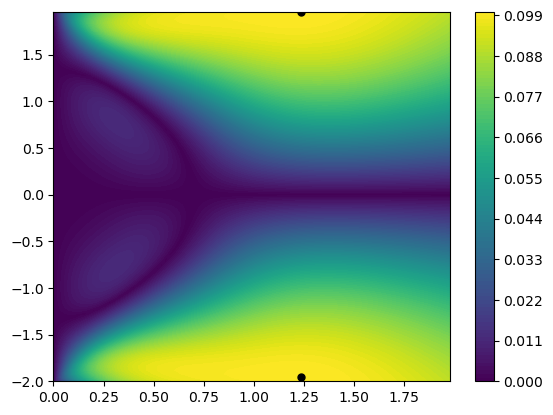

In [ ]:
# c_local = -np.mean(u.duality_pairing(kernel) - target)
p_u = p(u, c)
resolution = 100
a_sigma = np.linspace(0,2,resolution, endpoint=False)
a_omega = np.linspace(omega_space[0][0],omega_space[0][1],resolution, endpoint=False)
x, y = np.meshgrid(a_omega,a_omega)
points = np.array(list(zip(x.flatten(), y.flatten())))
vals = np.abs(p_u(points)).reshape((resolution,resolution))

plt.contourf(x, y, vals, levels=100);
for omega in u.support:
    plt.plot(omega[0], omega[1], "o", c="black", markersize=5);
plt.colorbar();
# plt.xlim(0,0.5)

In [192]:
p_u = p(u, c)
p_u(u.support)

Array([ 0.01, -0.01, -0.01, -0.01, -0.01,  0.01,  0.01,  0.01,  0.01,
        0.01,  0.01, -0.01, -0.01, -0.01, -0.01,  0.01], dtype=float64)

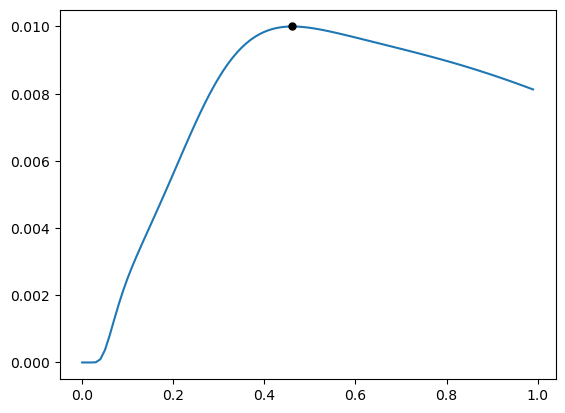

In [135]:
# c_local = -np.mean(u.duality_pairing(kernel) - target)
p_u = p(u, c)
resolution = 100
a_sigma = np.linspace(0,1,resolution, endpoint=False)
index = 3
points = np.array([u.support[index]]*resolution)
points[:,0]=a_sigma
vals = np.abs(p_u(points))

plt.plot(a_sigma, vals);
plt.plot([u.support[index][0]], np.abs(p_u(np.array([u.support[index]]))), "o", c="black", markersize=5);

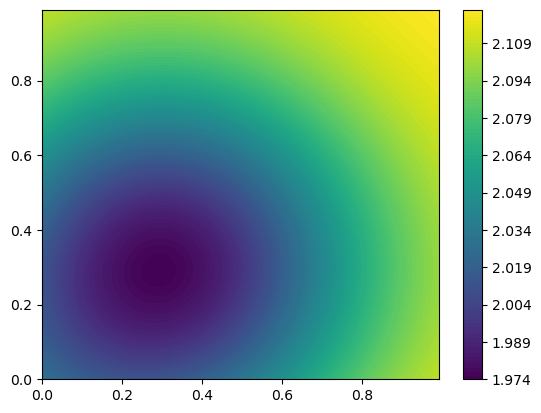

In [77]:
point = np.array([1,0.3,0.3,0.3,0.1]) # u.to_matrix().flatten()
resolution = 100
a_1 = np.linspace(0,1,resolution, endpoint=False)
a_2 = np.linspace(0,1,resolution, endpoint=False)
x, y = np.meshgrid(a_1,a_2)
raw_points = np.array(list(zip(x.flatten(), y.flatten())))
points = np.array([point]*len(raw_points))
points[:,2:4] = raw_points

# points = np.hstack((0.02*np.ones((points.shape[0],1)), points))
vals = np.log(jax.vmap(j_N)(points)).reshape((resolution,resolution))

plt.contourf(x, y, vals, levels=100);
plt.colorbar();

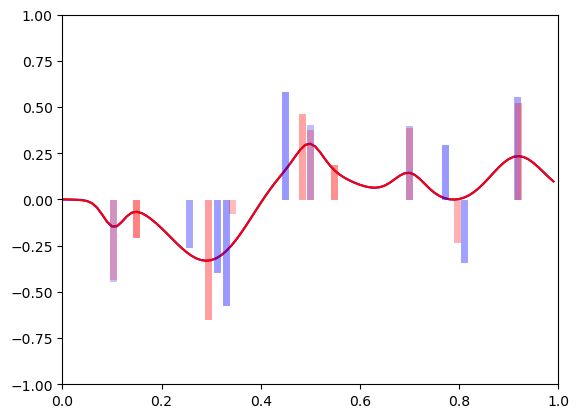

In [82]:
a = np.arange(0,1,0.01).reshape(-1,1)

def plot_kernel(omega: np.ndarray):
    sigma = omega[0]
    x_omega = omega[1:]
    inner = -(jnp.linalg.norm(x_omega - a,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**(variance_exponent))/(np.sqrt(2*np.pi)**d)
    return outer

true_vals = true_measure.duality_pairing(jax.vmap(plot_kernel)) # .reshape((100,100))
pred_vals = u.duality_pairing(jax.vmap(plot_kernel)) + c*np.ones(len(a))

plt.plot(a, true_vals, c="blue")
plt.plot(a, pred_vals, c="red");
plt.xlim(0,1);
plt.ylim(-1, 1);
signs = np.sign(true_weights)
for i, x in enumerate(true_sources):
    size = signs[i]*(0.01+np.sqrt(np.abs(true_weights[i]))*0.3)+0.5
    plt.axvline(x=x[1], ymin=min(0.5,size)+0.01,ymax=max(0.5, size)-0.01, linewidth=5, c="blue", alpha=sp.special.expit(np.log(np.sqrt(x[0]*5))));
signs = np.sign(u.coefficients)
for i, x in enumerate(u.support):
    size = signs[i]*(0.01+np.sqrt(np.abs(u.coefficients[i]))*0.3)+0.5
    plt.axvline(x=x[1], ymin=min(0.5,size)+0.01,ymax=max(0.5,size)-0.01, linewidth=5, c="red", alpha=sp.special.expit(np.log(np.sqrt(x[0]*5))));

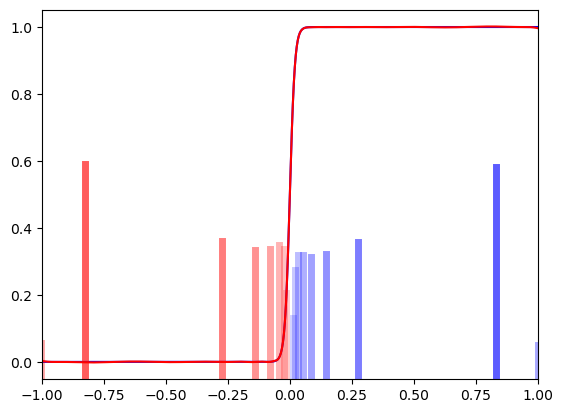

In [97]:
resolution = 1000
a = np.linspace(omega_space[0][0],omega_space[0][1],resolution,endpoint=False).reshape(-1,1)

def plot_kernel(omega: np.ndarray):
    sigma = omega[0]
    x_omega = omega[1:]
    inner = -(jnp.linalg.norm(x_omega - a,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**(variance_exponent))/(np.sqrt(2*np.pi)**d)
    return outer

true_vals = true_function(a)
pred_vals = u.duality_pairing(jax.vmap(plot_kernel)) + c*np.ones(len(a))

plt.plot(a, true_vals, c="blue")
plt.plot(a, pred_vals, c="red");
plt.xlim(omega_space[0][0],omega_space[0][1]);
signs = np.sign(u.coefficients)
for i, x in enumerate(u.support):
    if signs[i]>0:
        color = "blue"
    else:
        color = "red"
    size = (0.01+np.sqrt(np.abs(u.coefficients[i]))*0.5)
    plt.axvline(x=x[1], ymin=0.01,ymax=size-0.01, linewidth=5, c=color, alpha=sp.special.expit(np.log(np.sqrt(x[0]*5))));

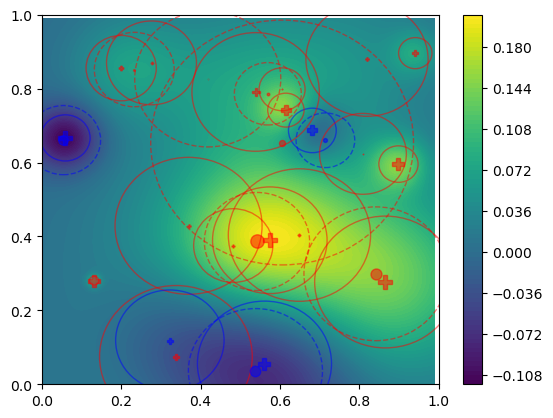

In [139]:
a = np.arange(0,1,0.01).reshape(-1,1)
B, C = np.meshgrid(a,a)
x = np.array(list(zip(B.flatten(), C.flatten())))

def plot_kernel(omega: np.ndarray):
    sigma = omega[0]
    x_omega = omega[1:]
    inner = -(jnp.linalg.norm(x_omega - x,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**variance_exponent)/(np.sqrt(2*np.pi)**d)
    return outer

true_vals = true_measure.duality_pairing(jax.vmap(plot_kernel)).reshape((100,100))
pred_vals = u.duality_pairing(jax.vmap(plot_kernel)).reshape((100,100))

fig, axes = plt.subplots()
plt.contourf(B, C, true_vals, levels=100);
plt.colorbar();
plt.xlim(0, 1);
plt.ylim(0, 1);
for i, x in enumerate(true_sources):
    if true_weights[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(true_weights[i])*10
    plt.plot([x[1]], [x[2]], "P", c=color, markersize=size, alpha=0.5);
    circle = plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5);
    axes.add_artist(circle);
for i, x in enumerate(u.support):
    if u.coefficients[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(u.coefficients[i])*10
    plt.plot([x[1]], [x[2]], "o", c=color, markersize=size, alpha=0.5);
    circle = plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5, linestyle="--");
    axes.add_artist(circle);

In [193]:
resolution = 150
a_1 = np.linspace(omega_space[0][0],omega_space[0][1],resolution, endpoint=False)
a_2 = np.linspace(omega_space[1][0],omega_space[1][1],resolution, endpoint=False)
x, y = np.meshgrid(a_1,a_2)
points = np.array(list(zip(x.flatten(), y.flatten())))
vals = true_function(points).reshape((resolution,resolution))

def plot_kernel(omega: np.ndarray):
    sigma = omega[0]
    x_omega = omega[1:]
    inner = -(jnp.linalg.norm(x_omega - points,axis=1)**2)/(2*sigma**2)
    outer = (jnp.exp(inner)*sigma**variance_exponent)/(np.sqrt(2*np.pi)**d)
    return outer

pred_vals = u.duality_pairing(jax.vmap(plot_kernel)).reshape((resolution,resolution)) +c*np.ones((resolution, resolution))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))
contour1 = ax1.contourf(x, y, vals, levels=100)
fig.colorbar(contour1, ax=ax1)
contour2 = ax2.contourf(x, y, pred_vals, levels=100)
fig.colorbar(contour2, ax=ax2)
contour3 = ax3.contourf(x, y, np.abs(pred_vals-vals), levels=100)
fig.colorbar(contour3, ax=ax3)
for i, x in enumerate(u.support):
    if u.coefficients[i] < 0:
        color = "b"
    else:
        color = "r"
    size = abs(u.coefficients[i])
    ax1.add_patch(plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5))
    ax2.add_patch(plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5))
    ax3.add_patch(plt.Circle((x[1], x[2]), radius=x[0], color=color, fill=False, alpha=0.5))
ax1.set_xlim(omega_space[0][0],omega_space[0][1])
ax1.set_ylim(omega_space[1][0],omega_space[1][1])
ax2.set_xlim(omega_space[0][0],omega_space[0][1])
ax2.set_ylim(omega_space[1][0],omega_space[1][1])
ax3.set_xlim(omega_space[0][0],omega_space[0][1])
ax3.set_ylim(omega_space[1][0],omega_space[1][1])

ValueError: Incompatible shapes for broadcasting: shapes=[(4,), (22500, 2)]

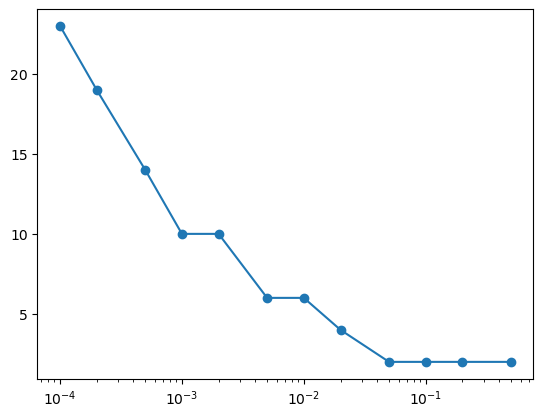

In [295]:
x = np.array([1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 5e-1])
y = np.array([23, 19, 14, 10, 10, 6, 6, 4, 2, 2, 2, 2])
plt.semilogx(x, y, marker="o");

# Function Approximation (Sigmoid Shallow NN)

## Generate Data and Define Functions

In [61]:
alpha = 1e-6

In [62]:
# Function approximation
observation_size = 100
observation_space = np.array([[0,1], [0,1]])
Omega = np.array([[0,1], [0,1], [0,1]])
true_function = lambda x: np.sin(10*(x[0]**2+x[1]**2))

np.random.seed(49)
columns = []
for bounds in observation_space:
    columns.append(
        np.random.sample((observation_size, 1)) * (bounds[1] - bounds[0]) + bounds[0]
    )
observations = np.concatenate(columns, axis=1)
observations_bias = np.append(np.ones((observations.shape[0],1)),observations,axis=1)
target = np.array([true_function(x) for x in observations])

In [63]:
activation = lambda omega: 1/(1+np.exp(omega)) # sigmoid
def kappa(x):
    # input is a 2D array of shape (number of points, dimension of observation space +1)
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    linear_operation = x@(observations_bias.T)
    activated = activation(linear_operation)
    return activated # shape (len(x), len(observations))

In [64]:
def activation_grad(omega: np.ndarray) -> np.ndarray:
    sigmoid = activation(omega)
    return sigmoid * (1 - sigmoid)  # Derivative of the sigmoid function

def grad_kappa(x):
    # input is a 2D array of shape (number of points, dimension of observation space +1)
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    linear_operation = x@(observations_bias.T)
    activated = activation_grad(linear_operation) # shape=(len(x), len(observations))
    inner_derivative = np.repeat(np.expand_dims(observations_bias,axis=0),len(x),axis=0) # shape=(len(x), len(observations), Omega.shape[0])
    chain_rule = np.multiply(activated.reshape((len(x),len(observations),1)), inner_derivative)
    return chain_rule # shape (len(x), len(observations), Omega.shape[0])

In [65]:
def activation_hess(omega: np.ndarray) -> np.ndarray:
    sigmoid = activation(omega)
    return sigmoid * (1 - sigmoid)*(1-2*sigmoid)  # Derivative of the sigmoid function

def hess_kappa(x):
    # Input is 2D array of shape (number of points, dimension of observation space +1)
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    linear_operation = x@(observations_bias.T)
    activated = activation_hess(linear_operation)
    inner_second_derivative_raw = np.array([np.outer(vect, vect) for vect in observations_bias]) # shape (len(observations),Omega.shape[0],Omega.shape[0])
    inner_second_derivative = np.repeat(np.expand_dims(inner_second_derivative_raw,axis=0),len(x),axis=0) # shape (len(x),len(observations),Omega.shape[0],Omega.shape[0])
    chain_rule = np.multiply(activated.reshape((len(x),len(observations),1,1)), inner_second_derivative)
    return chain_rule # shape (len(x), len(observations), Omega.shape[0], Omega.shape[0])

In [66]:
g = lambda u: alpha * np.linalg.norm(u, ord=1)
f = lambda u: 0.5 * np.linalg.norm(u.duality_pairing(kappa) - target) ** 2

In [67]:
def p_raw(u):
    Ku = u.duality_pairing(kappa)
    inner = Ku-target
    return lambda x: -kappa(x) @ inner

p = lambda u: p_raw(u)

In [68]:
def grad_P_raw(u):
    p_u = p_raw(u)
    inner = target-u.duality_pairing(kappa)
    return lambda x: np.sign(p_u(x)).reshape(-1,1)*np.tensordot(grad_kappa(x), inner, axes=([1,0]))

grad_P = lambda u: grad_P_raw(u)

In [69]:
def grad_P_raw_sphere(u):
    p_u = p_raw(u)
    inner = target-u.duality_pairing(kappa)
    def grad_P_x(x):
        unprojected = np.sign(p_u(x)).reshape(-1,1)*np.tensordot(grad_kappa(x), inner, axes=([1,0]))
        to_return = np.zeros(unprojected.shape)
        for i, (grad ,position) in enumerate(zip(unprojected, x)):
            # Project onto the ball
            projection = np.eye(len(position)) - np.outer(position, position)
            to_return[i] = projection@grad
        return to_return
    return grad_P_x

grad_P_sphere = lambda u: grad_P_raw_sphere(u)

In [70]:
def hess_P_raw(u):
    p_u = p_raw(u)
    inner = target-u.duality_pairing(kappa)
    return lambda x: np.sign(p_u(x)).reshape(-1,1,1)*np.tensordot(hess_kappa(x),inner,axes=([1,0]))

hess_P = lambda u: hess_P_raw(u)

In [71]:
def hess_P_raw_sphere(u):
    p_u = p_raw(u)
    grad_u = grad_P(u)
    inner = target-u.duality_pairing(kappa)
    def hess_P_x(x):
        grads = grad_u(x)
        unprojected = np.sign(p_u(x)).reshape(-1,1,1)*np.tensordot(hess_kappa(x),inner,axes=([1,0]))
        to_return = np.zeros(unprojected.shape)
        for i, (grad, hess, position) in enumerate(zip(grads, unprojected, x)):
            # P_x(hess-position.T*grad*I)
            projection = np.eye(len(position)) - np.outer(position, position)
            identity_factor = position@grad
            to_return[i] = projection@(hess-identity_factor*np.eye(len(position)))@projection
        return to_return
    return hess_P_x

hess_P_sphere = lambda u: hess_P_raw_sphere(u)

In [72]:
def grad_j(positions, coefs):
    K_matrix = kappa(positions)
    grad_F = (K_matrix.T@coefs).flatten() - target
    nabla_x = coefs.reshape(-1,1)*np.tensordot(grad_kappa(positions), grad_F, axes=([1,0]))
    nabla_u = np.dot(K_matrix, grad_F) + alpha * np.sign(coefs)
    return np.append(nabla_x.flatten(), nabla_u, axis=0).flatten()

In [73]:
def grad_j_sphere(positions, coefs):
    K_matrix = kappa(positions)
    grad_F = (K_matrix.T@coefs).flatten() - target
    nabla_x = coefs.reshape(-1,1)*np.tensordot(grad_kappa(positions), grad_F, axes=([1,0]))
    for i, (grad ,position) in enumerate(zip(nabla_x, positions)):
        # Project onto the ball
        nabla_x[i] = (np.eye(len(position))-np.outer(position, position))@grad
    nabla_u = np.dot(K_matrix, grad_F) + alpha * np.sign(coefs)
    return np.append(nabla_x.flatten(), nabla_u, axis=0).flatten()

In [74]:
def hess_j(positions, coefs):
    kappa_values = kappa(positions)
    grad_kappa_values = grad_kappa(positions)
    hess_kappa_values = hess_kappa(positions)
    matrix_dimension = len(positions)*Omega.shape[0] + len(coefs)
    hesse_matrix = np.zeros((matrix_dimension, matrix_dimension))
    step = Omega.shape[0]
    coefs_delay = step*len(positions)
    inner = (kappa_values.T@coefs).flatten() - target
    for i in range(len(positions)):
        # nabla_{x_i,x_j}
        for j in range(len(positions)):
            if j<i:
                continue
            block = coefs[i]*coefs[j]*np.matmul(grad_kappa_values[i].T, grad_kappa_values[j])
            if i==j:
                block += coefs[i]*np.tensordot(hess_kappa_values[i],inner,axes=([0,0]))
            hesse_matrix[i*step:(i+1)*step, j*step:(j+1)*step] = block
            hesse_matrix[j*step:(j+1)*step, i*step:(i+1)*step] = block.T
        # nabla_{x_i,u_j}
        for j in range(len(coefs)):
            block = coefs[i]*np.matmul(grad_kappa_values[i].T, kappa_values[j])
            if i == j:
                block += np.matmul(grad_kappa_values[i].T, inner)
            hesse_matrix[i*step:(i+1)*step, coefs_delay+j] = block
            hesse_matrix[coefs_delay+j, i*step:(i+1)*step] = block.T
    for i in range(len(coefs)):
        # nabla_{u_i,u_j}
        for j in range(len(coefs)):
            if j<i:
                continue
            block = np.dot(kappa_values[i], kappa_values[j])
            hesse_matrix[coefs_delay+i,coefs_delay+j] = block
            hesse_matrix[coefs_delay+j,coefs_delay+i] = block
    return hesse_matrix

In [75]:
def hess_j_sphere(positions, coefs):
    hessian = hess_j(positions, coefs)
    gradient = grad_j(positions, coefs)
    projection = np.eye(hessian.shape[0])
    inner_matrix = np.eye(hessian.shape[0])
    for i, position in enumerate(positions):
        projection_part = np.eye(len(position))-np.outer(position, position)
        inner_matrix_part = (position@gradient[i*len(position):(i+1)*len(position)])*np.eye(len(position))
        projection[i*len(position):(i+1)*len(position), i*len(position):(i+1)*len(position)] = projection_part
        inner_matrix[i*len(position):(i+1)*len(position), i*len(position):(i+1)*len(position)] = inner_matrix_part
    hesse_system = projection@(hessian-inner_matrix)@projection
    return hesse_system

## Experiments

In [ ]:
exp = NLGCG(target=target, 
           kappa=kappa, 
           g=g, 
           f=f,
           p=p,
           grad_P=grad_P_sphere,
           hess_P=hess_P_sphere,
           grad_j=grad_j_sphere,
           hess_j=hess_j_sphere,
           alpha=alpha,
           Omega=Omega,
           global_search_resolution=100,
           dual_variable_goodness=0.3,
           projection="sphere"
           )

In [77]:
u, times, supports, inner_loop, lgcg_lazy, lgcg_total, objective_values, dropped_tot, epsilons = exp.nlgcg(tol=1e-12, max_radius=0.1)

INFO:root:Radii: []
DEBUG:root:SSN in 181 dimensions converged in 11 iterations to tolerance 1.000E-12
INFO:root:0: choice: 0, lazy: True, support: 0, epsilon: 1.3209093658606576e-05, c_raw: 8192.0, objective: 2.641819E+01
INFO:root:=============================================================================================
INFO:root:Radii: [0.1]
INFO:root:1, 1: lazy: N/A, support: 1, epsilon: 1.3209093658606576e-05, c_raw: 8192.0 objective: 2.617532E+01
INFO:root:norm_grad: 0.03166117765420083, constant: 0.010389193788632607, diff: 0.07478477022451457, smallest eival: -1.768E-01, largest eival: 2.406E+01
INFO:root:Inequalities 6.6: [False, True, False]
DEBUG:root:SSN in 5 dimensions converged in 19 iterations to tolerance 1.000E-12
INFO:root:1: choice: 0, lazy: True, support: 1, epsilon: 1.3209093658606576e-05, c_raw: 4096.0, objective: 2.617532E+01
INFO:root:=============================================================================================
INFO:root:Radii: [0.1, 0.1, 0.1]

KeyboardInterrupt: 

## Plots

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x7f4c41b2e020>


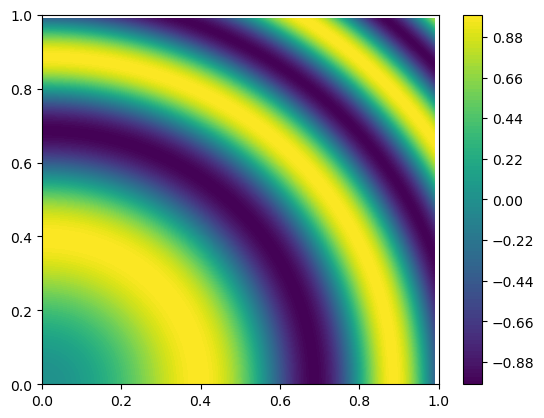

In [60]:
a = np.arange(0,1,0.01)
B, D = np.meshgrid(a,a)
X = np.array(list(zip(B.flatten(), D.flatten())))
true_vals = np.array([true_function(x) for x in X]).reshape((100,100))

plt.contourf(B, D, true_vals, levels=100);
plt.colorbar();
plt.xlim(Omega[0][0], Omega[0][1]);
plt.ylim(Omega[1][0], Omega[1][1]);

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x7f4c4365c670>


L2 error: 6.382E-03, Linf error: 2.641E-02


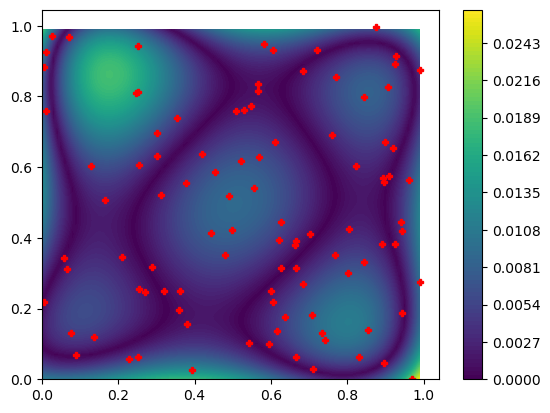

In [44]:
def predicted(x):
    # Input is 2D array of shape (number of points, Omega dimension)
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    x_bias = np.append(np.ones((x.shape[0],1)),x,axis=1)
    activated = activation(x_bias@u.support.T) # shape (len(x), len(observations))
    output = np.dot(activated, u.coefficients) # shape (len(x),)
    return output

a = np.arange(0,1,0.01)
B, D = np.meshgrid(a,a)
x = np.array(list(zip(B.flatten(), D.flatten())))
pred_vals = predicted(x).reshape((100,100))
error = true_vals - pred_vals

print(f"L2 error: {np.linalg.norm(error)/np.sqrt(len(x)):.3E}, Linf error: {np.max(np.abs(error)):.3E}")

plt.contourf(B, D, np.abs(error), levels=100);
plt.colorbar();
for i, x in enumerate(observations):
    plt.plot([x[0]], [x[1]], "P", c="r", markersize=4);